# Composer Classification from Symbolic MIDI

This master notebook is the shared experiment flow for the AAI-511 project. It builds a clean file-level manifest, runs exploratory analysis, trains the LSTM and CNN models, and keeps the test set unused during model development.

Reusable implementation lives in `src/`. The runtime selects an available hardware accelerator or CPU. Before running this notebook for the first time, configure Kaggle credentials and run `pixi run prepare-dataset` from the repository root so the raw corpus is available under `dataset/raw/`. MIDI-level EDA is parsed once and cached in `dataset/processed/eda_metadata.csv`; this notebook then presents the cached summary tables and figures.

In [1]:
from pathlib import Path
import sys

import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from experiments import (
    ExperimentConfig,
    prepare_experiment,
    run_cnn_baseline,
    run_lstm_baseline,
)
from project_config import RAW_DATA_DIR
from visualization import (
    plot_cnn_results,
    plot_eda_analysis,
    plot_exploration,
    plot_lstm_results,
)

CONFIG = ExperimentConfig(
    max_sequence_length=4096,
    epochs=20,
    learning_rate=1e-3,
    # Set True only after changing EDA metadata features.
    refresh_eda=False,
)

print(f"Repository: {REPO_ROOT}")
print(f"Raw data: {RAW_DATA_DIR / 'midiclassics'}")

Repository: /Users/marston.ward/Developer/personal/AAI-511/final-project/music-composer-classification-pytorch
Raw data: /Users/marston.ward/Developer/personal/AAI-511/final-project/music-composer-classification-pytorch/dataset/raw/midiclassics


/Users/marston.ward/Developer/personal/AAI-511/final-project/music-composer-classification-pytorch/.pixi/envs/default/lib/python3.12/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Clean files: 1608
Newly excluded files: 0
Normalization statistics: {'velocity': (79.99657440185547, 23.89927101135254), 'duration': (0.35103198885917664, 0.49335524439811707), 'time_interval': (0.09354662150144577, 0.17110909521579742)}
PCA explained variance: PC1=47.1%, PC2=18.5%, cumulative=65.6%


split,train,validation,test,total
composer,,,,
Bach,709,152,153,1014
Beethoven,146,31,31,208
Chopin,92,20,20,132
Mozart,178,38,38,254


,duration_s,tempo_bpm,note_count,note_density,pitch_range,mean_pitch
composer,,,,,,
Bach,160.26,89.68,1687.37,9.29,43.09,62.33
Beethoven,518.31,123.30,8051.99,14.48,61.07,63.74
Chopin,222.29,111.96,2509.78,11.57,62.98,62.93
Mozart,415.52,104.90,5475.17,13.69,55.31,64.86


,duration_s,tempo_bpm,note_count,note_density,pitch_range,mean_pitch
duration_s,1.000,0.036,0.692,0.179,0.487,0.243
tempo_bpm,0.036,1.000,0.236,0.391,0.215,0.110
note_count,0.692,0.236,1.000,0.645,0.598,0.224
note_density,0.179,0.391,0.645,1.000,0.505,0.213
pitch_range,0.487,0.215,0.598,0.505,1.000,0.298
mean_pitch,0.243,0.110,0.224,0.213,0.298,1.000


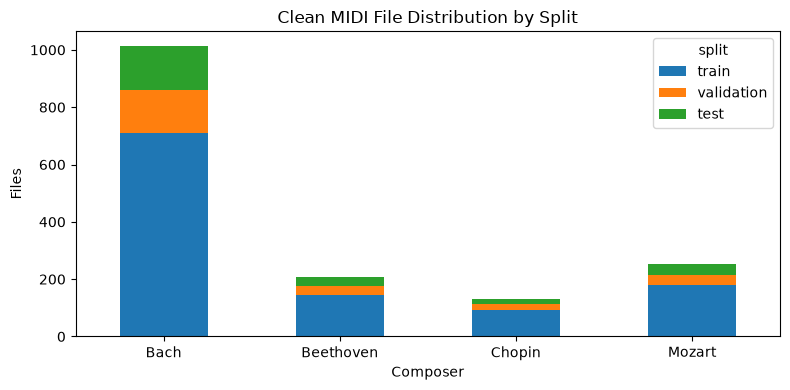

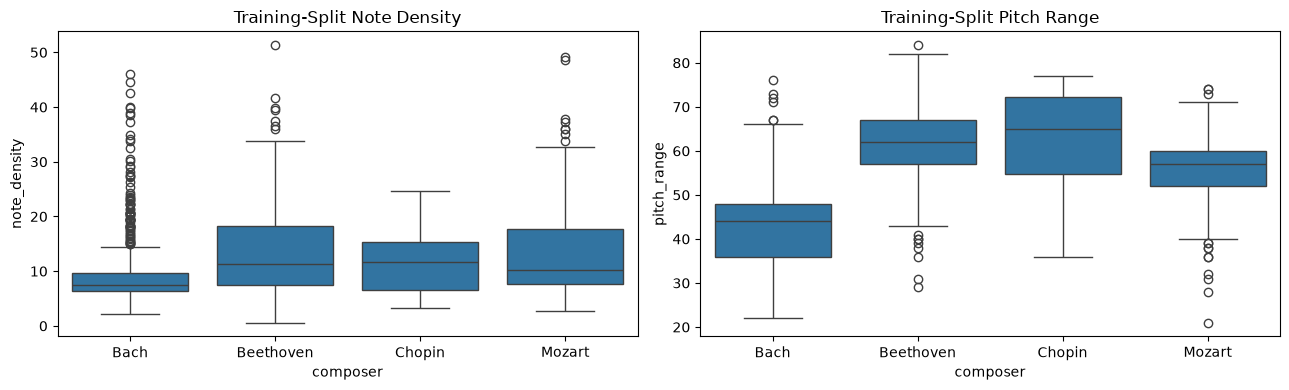

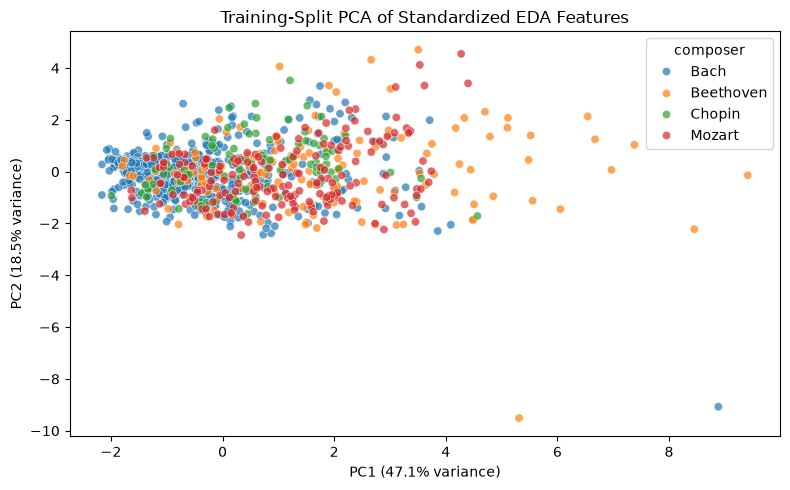

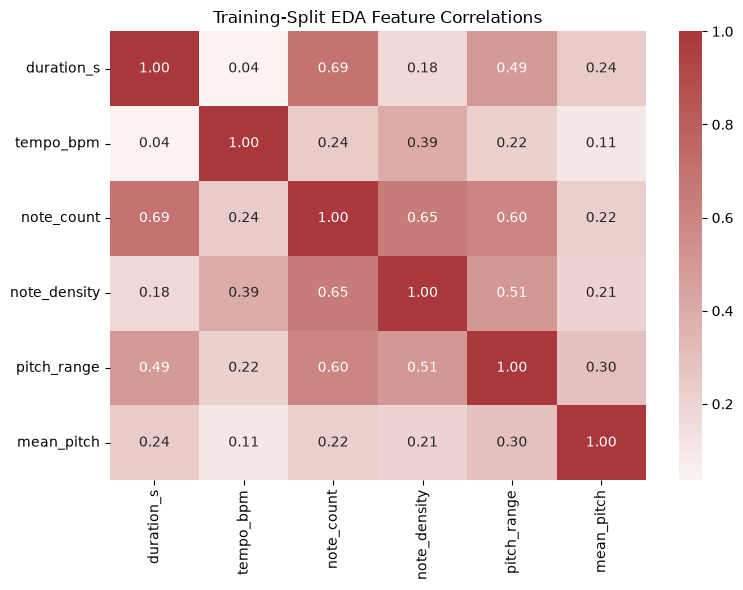

In [2]:
experiment = prepare_experiment(CONFIG)

first_pc, second_pc = experiment.eda_analysis.explained_variance_ratio
print(f"Clean files: {len(experiment.manifest)}")
print(f"Newly excluded files: {len(experiment.exclusions)}")
print(f"Normalization statistics: {experiment.split_features.normalization}")
print(f"PCA explained variance: PC1={first_pc:.1%}, PC2={second_pc:.1%}, cumulative={first_pc + second_pc:.1%}")
display(experiment.inventory)
display(experiment.eda_summary)
display(experiment.eda_analysis.correlation.round(3))

plot_exploration(experiment.inventory, experiment.train_metadata);
plot_eda_analysis(experiment.eda_analysis);

## LSTM Baseline

The baseline is a PyTorch LSTM that combines an embedding of MIDI pitch tokens with velocity, note duration, and time-interval features. Its architecture is defined in `src/models.py`. The shared training workflow in `src/experiments.py` includes inverse-frequency class weighting, Adam weight decay, validation checkpoint selection, and early stopping.

The next cell trains the model on the fixed training split and presents the model structure, class weights, selected-checkpoint training and validation accuracy, validation report, loss curve, and confusion matrix. The test split remains unused.

Epoch 01/20 | train loss 1.3125 | train accuracy 0.5396 | validation loss 1.0951 | validation accuracy 0.6349


Epoch 02/20 | train loss 1.1400 | train accuracy 0.6391 | validation loss 1.0097 | validation accuracy 0.6017


Epoch 03/20 | train loss 1.0628 | train accuracy 0.6542 | validation loss 0.8556 | validation accuracy 0.6639


Epoch 04/20 | train loss 0.9901 | train accuracy 0.6667 | validation loss 0.8513 | validation accuracy 0.6515


Epoch 05/20 | train loss 0.9442 | train accuracy 0.6978 | validation loss 0.8519 | validation accuracy 0.7054


...

Epoch 09/20 | train loss 0.7476 | train accuracy 0.7413 | validation loss 0.8078 | validation accuracy 0.6929


Epoch 10/20 | train loss 0.6860 | train accuracy 0.7707 | validation loss 0.7276 | validation accuracy 0.7427


Epoch 11/20 | train loss 0.6631 | train accuracy 0.7822 | validation loss 0.7375 | validation accuracy 0.7303
Early stopping at epoch 11: no validation improvement in 5 epochs (best epoch 06).


LSTMComposerClassifier(
  (embedding): Embedding(129, 32, padding_idx=0)
  (lstm): LSTM(35, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=64, out_features=4, bias=True)
)
Class weights: [0.397 1.926 3.057 1.58 ]
Selected-checkpoint training accuracy: 0.741
Best validation accuracy: 0.759


,precision,recall,f1-score,support
0,0.862,0.908,0.885,152.000
1,0.533,0.258,0.348,31.000
2,0.765,0.650,0.703,20.000
3,0.490,0.632,0.552,38.000
accuracy,0.759,0.759,0.759,0.759
macro avg,0.663,0.612,0.622,241.000
weighted avg,0.753,0.759,0.748,241.000


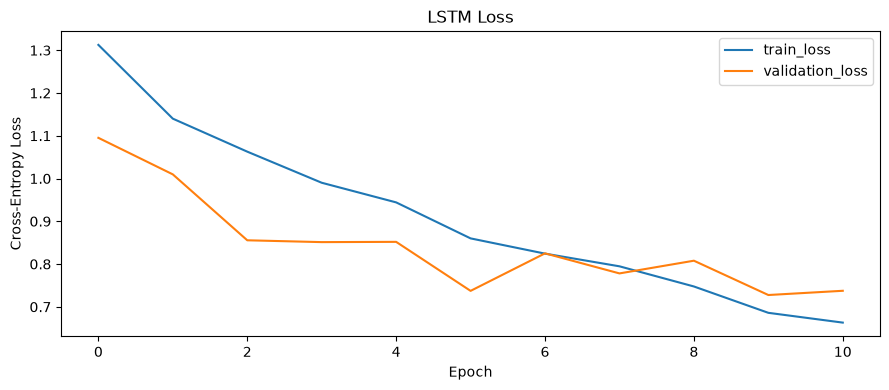

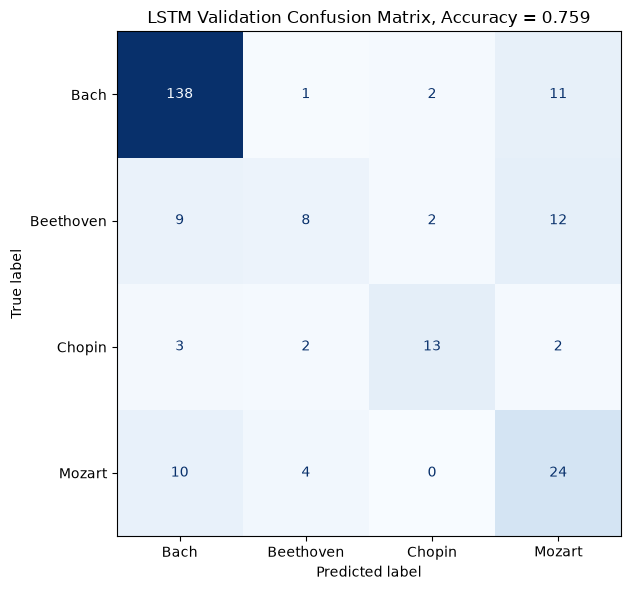

In [3]:
baseline = run_lstm_baseline(experiment, CONFIG)

print(baseline.model)
print(f"Class weights: {baseline.class_weights.numpy().round(3)}")
print(f"Selected-checkpoint training accuracy: {baseline.training.accuracy:.3f}")
print(f"Best validation accuracy: {baseline.validation.accuracy:.3f}")
display(pd.DataFrame(baseline.validation.report).transpose().round(3))

plot_lstm_results(baseline.history, baseline.validation);

## CNN Baseline

The CNN uses the same pitch embedding, normalized velocity, duration, and onset-interval features as the LSTM, but learns local musical patterns with three one-dimensional convolutional blocks. Two max-pooling stages reduce the sequence before adaptive global max pooling produces a piece-level representation.

The CNN is trained from the same fixed manifest, class-weighted loss, Adam weight decay, and early-stopping policy as the LSTM. Its selected checkpoint is evaluated consistently on both the training and validation loaders, while the test split remains sealed until the final architectures have been selected.

Epoch 01/20 | train loss 1.3775 | train accuracy 0.4729 | validation loss 0.8522 | validation accuracy 0.6680


Epoch 02/20 | train loss 1.1038 | train accuracy 0.5929 | validation loss 0.8215 | validation accuracy 0.6307


Epoch 03/20 | train loss 0.9692 | train accuracy 0.6382 | validation loss 0.7281 | validation accuracy 0.7344


Epoch 04/20 | train loss 0.8202 | train accuracy 0.6960 | validation loss 0.8002 | validation accuracy 0.6929


Epoch 05/20 | train loss 0.7737 | train accuracy 0.7271 | validation loss 0.6169 | validation accuracy 0.7801


...

Epoch 18/20 | train loss 0.1645 | train accuracy 0.9502 | validation loss 0.8394 | validation accuracy 0.8216


Epoch 19/20 | train loss 0.1127 | train accuracy 0.9644 | validation loss 0.8790 | validation accuracy 0.7842


Epoch 20/20 | train loss 0.1110 | train accuracy 0.9680 | validation loss 1.1195 | validation accuracy 0.8050


CNNComposerClassifier(
  (embedding): Embedding(129, 32, padding_idx=0)
  (conv_block_1): Sequential(
    (0): Conv1d(35, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_3): Sequential(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (global_pool): AdaptiveMaxPool1d(output_size=1)
  (dropout): Dropout(p=0.3, inplace=False)
  (cl

,precision,recall,f1-score,support
0,0.885,0.961,0.921,152.000
1,0.576,0.613,0.594,31.000
2,0.667,0.800,0.727,20.000
3,0.895,0.447,0.596,38.000
accuracy,0.822,0.822,0.822,0.822
macro avg,0.756,0.705,0.710,241.000
weighted avg,0.829,0.822,0.812,241.000


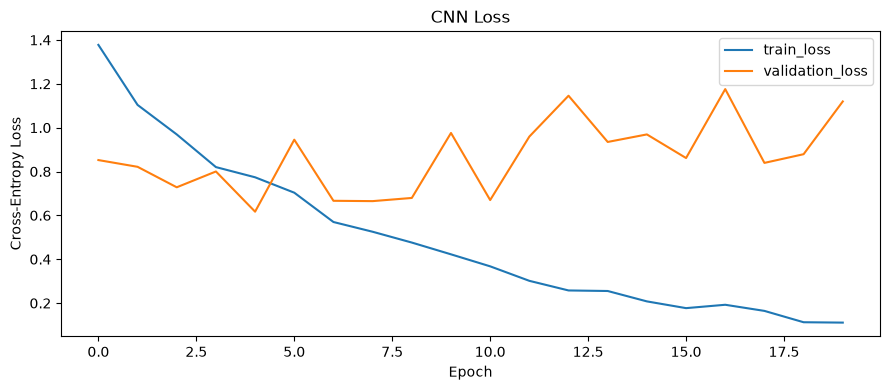

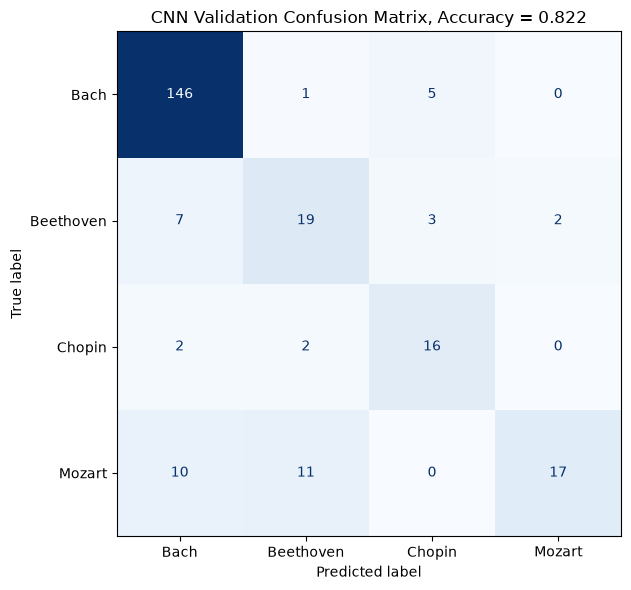

In [4]:
cnn_baseline = run_cnn_baseline(experiment, CONFIG)

print(cnn_baseline.model)
print(f"Class weights: {cnn_baseline.class_weights.numpy().round(3)}")
print(f"Selected-checkpoint training accuracy: {cnn_baseline.training.accuracy:.3f}")
print(f"Best validation accuracy: {cnn_baseline.validation.accuracy:.3f}")
display(pd.DataFrame(cnn_baseline.validation.report).transpose().round(3))

plot_cnn_results(cnn_baseline.history, cnn_baseline.validation);